Setup complete.
Loaded: 26576 16081 18876
       year               test                        term   coef      p   ci_lo  ci_hi  max_abs_d
       2024     H1_main_ai_use                      ai_use 0.1411 0.0000     NaN    NaN        NaN
       2024     H2_interaction ai_use:C(remote3)[T.Hybrid] 0.0868 0.2354 -0.0566 0.2302     0.1111
       2024     H2_interaction ai_use:C(remote3)[T.Remote] 0.1312 0.0790 -0.0152 0.2776     0.1340
       2024 H2_interaction_LRT                  chi2(df=2) 3.0893 0.2134     NaN    NaN        NaN
       2024    H3_random_slope         var(ai_use|country) 0.0001 1.0000     NaN    NaN        NaN
       2025     H1_main_ai_use                      ai_use 0.1265 0.0009     NaN    NaN        NaN
       2025     H2_interaction ai_use:C(remote3)[T.Hybrid] 0.1460 0.1820 -0.0684 0.3604     0.1874
       2025     H2_interaction ai_use:C(remote3)[T.Remote] 0.1754 0.1161 -0.0434 0.3942     0.2050
       2025 H2_interaction_LRT                  chi2(df=2) 2.5557 0

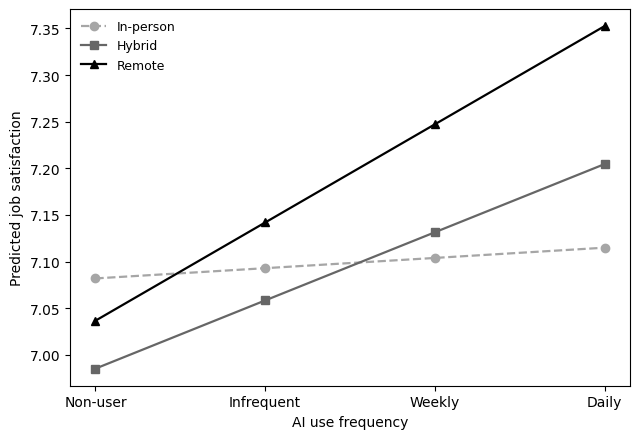

Figure saved: results/figures/simple_slopes_2025.png (grayscale, 600 dpi, model-predicted)
Tables saved:
  results/tables/main_results.csv
  results/tables/intensity_2025.csv
  results/tables/simple_slopes_2025.csv
Analysis complete.
H1 supported (small); H2 rejected & replicated; H3 rejected;
intensity gradient is exploratory (2025 only, coding-sensitive).


In [2]:
# ============================================================================
# Notebook: 03_analysis.ipynb
#
# Verification Channels and Remote Work — multilevel analysis
#
# Reads data/processed/ analytic samples, fits H1-H5 + replication and the
# exploratory 2025 intensity analysis (via src/models.py), and saves:
#   results/tables/   main_results.csv, intensity_2025.csv, simple_slopes_2025.csv
#   results/figures/  simple_slopes_2025.png
#
# Findings (confirmed): H1 supported (small), H2 rejected (null, replicated),
# H3 rejected; intensity shows an exploratory In-person<Hybrid<Remote gradient
# that is sensitive to coding and cannot be replicated in 2024.
#
# Runs from the notebooks/ folder; project root is one level up.
# ============================================================================


# %%
# ---------------------------------------------------------------------------
# Cell 1 | Paths, imports, output dirs
# ---------------------------------------------------------------------------
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = ROOT / "data" / "processed"
TAB_DIR = ROOT / "results" / "tables"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# src/ 를 경로에 추가한 뒤에 import 해야 함
sys.path.insert(0, str(ROOT / "src"))
from models import summarize_year, intensity_2025, intensity_predictions_2025

print("Setup complete.")


# %%
# ---------------------------------------------------------------------------
# Cell 2 | Load analytic samples
# ---------------------------------------------------------------------------
s24 = pd.read_csv(PROC_DIR / "analysis_2024.csv")
s25 = pd.read_csv(PROC_DIR / "analysis_2025.csv")
r25_rob = pd.read_csv(PROC_DIR / "analysis_2025_robust.csv")
print("Loaded:", len(s24), len(s25), len(r25_rob))


# %%
# ---------------------------------------------------------------------------
# Cell 3 | Main models H1-H3 (+ H5 CIs) for each dataset
# ---------------------------------------------------------------------------
res24, fit24 = summarize_year(s24, "2024")
res25, fit25 = summarize_year(s25, "2025")
res_rob, fit_rob = summarize_year(r25_rob, "2025_robust")

main_results = pd.concat([res24, res25, res_rob], ignore_index=True)
# order columns nicely
cols = ["year", "test", "term", "coef", "p", "ci_lo", "ci_hi", "max_abs_d"]
main_results = main_results.reindex(columns=cols)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(main_results.to_string(index=False))


# %%
# ---------------------------------------------------------------------------
# Cell 4 | Replication read-off (H2 interaction terms, 2024 vs 2025)
# ---------------------------------------------------------------------------
rep = main_results[main_results["test"] == "H2_interaction"][
    ["year", "term", "coef", "p", "ci_lo", "ci_hi"]
]
print("Replication comparison — H2 interaction terms:")
print(rep.to_string(index=False))
print("\nInteraction-only LRT (the clean H2 test):")
print(main_results[main_results["test"] == "H2_interaction_LRT"]
      [["year", "term", "coef", "p"]].to_string(index=False))


# %%
# ---------------------------------------------------------------------------
# Cell 5 | Exploratory intensity analysis (2025 only, ai_freq)
# ---------------------------------------------------------------------------
inten, slopes = intensity_2025(s25)
print("Intensity interaction across specifications:")
print(inten.to_string(index=False))
print("\nSimple slopes of ai_freq within each work arrangement:")
print(slopes.to_string(index=False))


# %%
# ---------------------------------------------------------------------------
# Cell 6 | Figure — model-predicted jobsat by AI frequency and work arrangement
#
# Uses actual fitted values from jobsat ~ ai_freq*C(remote3) + controls
# (random intercept), controls held at reference (workexp_z=0, modal devgroup).
# Intercept differences between arrangements are preserved. Grayscale, 600 dpi,
# no caption (add in manuscript). Exploratory, 2025 only.
# ---------------------------------------------------------------------------
pred = intensity_predictions_2025(s25)

fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Grayscale: distinguish arrangements by shade + marker + linestyle (not color).
gray_styles = {
    "In-person": dict(color="0.65", marker="o", linestyle="--"),  # flat, non-sig
    "Hybrid":    dict(color="0.40", marker="s", linestyle="-"),
    "Remote":    dict(color="0.00", marker="^", linestyle="-"),
}

x = [0, 1, 2, 3]
for lvl in ["In-person", "Hybrid", "Remote"]:
    st = gray_styles[lvl]
    y = pred.loc[pred["remote3"] == lvl].sort_values("ai_freq")["pred"].values
    ax.plot(x, y, color=st["color"], marker=st["marker"], linestyle=st["linestyle"],
            markersize=6, linewidth=1.6, label=lvl)

ax.set_xticks(x)
ax.set_xticklabels(["Non-user", "Infrequent", "Weekly", "Daily"])
ax.set_xlabel("AI use frequency")
ax.set_ylabel("Predicted job satisfaction")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "simple_slopes_2025.png", dpi=600)
plt.show()
print("Figure saved: results/figures/simple_slopes_2025.png (grayscale, 600 dpi, model-predicted)")


# %%
# ---------------------------------------------------------------------------
# Cell 7 | Save tables
# ---------------------------------------------------------------------------
main_results.to_csv(TAB_DIR / "main_results.csv", index=False)
inten.to_csv(TAB_DIR / "intensity_2025.csv", index=False)
slopes.to_csv(TAB_DIR / "simple_slopes_2025.csv", index=False)

print("Tables saved:")
for f in ["main_results.csv", "intensity_2025.csv", "simple_slopes_2025.csv"]:
    print("  results/tables/" + f)


# %%
# ---------------------------------------------------------------------------
# Cell 8 | Done
# ---------------------------------------------------------------------------
print("Analysis complete.")
print("H1 supported (small); H2 rejected & replicated; H3 rejected;")
print("intensity gradient is exploratory (2025 only, coding-sensitive).")

In [3]:
# %%
# ---------------------------------------------------------------------------
# Cell 4b | Equivalence testing (TOST) for the H2 interaction terms
#
# A non-significant LRT is ambiguous: absence of moderation vs. lack of power.
# To defend the null on effect-size grounds, we test whether each interaction
# coefficient is statistically equivalent to zero within bounds small enough to
# be practically negligible (two one-sided tests; Lakens 2018).
#
# We reuse the coefficients and 95% CIs already in `main_results` (H2_interaction
# rows) and recover each standard error from the CI half-width, so this cell does
# not depend on the internals of the fitted model objects.
#
# SESOI: half a standard deviation of job satisfaction, computed per sample on
# the same analytic data used for the models. Reported on the raw 0-10 scale AND
# in SD units so the manuscript's "in SD" statements map directly.
#
# Outputs: results/tables/equivalence_2025.csv  (feeds Table `tab:equiv`)
# ---------------------------------------------------------------------------
import numpy as np
from scipy.stats import norm

# --- SESOI configuration ----------------------------------------------------
SESOI_SD_FRACTION = 0.5   # equivalence bound = 0.5 * SD(jobsat); adjust if desired
ALPHA = 0.05              # for the smallest-bound-that-still-passes calculation
Z_CRIT = norm.ppf(1 - ALPHA)

# Job-satisfaction column name in the analytic samples.
# Change here if your processed files use a different name (e.g. "job_sat").
JOBSAT_COL = "jobsat"

# Standard deviation of the outcome in each sample (used to define the SESOI).
sd_by_sample = {
    "2024":        s24[JOBSAT_COL].std(ddof=1),
    "2025":        s25[JOBSAT_COL].std(ddof=1),
    "2025_robust": r25_rob[JOBSAT_COL].std(ddof=1),
}
print("SD(jobsat) by sample:",
      {k: round(v, 3) for k, v in sd_by_sample.items()})


def tost_two_one_sided(beta, se, sesoi):
    """
    Two one-sided tests that the true effect lies within [-sesoi, +sesoi].

    Returns p_tost = max(p_lower, p_upper). Equivalence at level alpha holds
    when p_tost < alpha, i.e. the effect is statistically distinguishable from
    both bounds.
    """
    # H0: beta <= -sesoi   (test that beta is greater than the lower bound)
    p_lower = norm.sf((beta - (-sesoi)) / se)
    # H0: beta >= +sesoi   (test that beta is less than the upper bound)
    p_upper = norm.cdf((beta - (sesoi)) / se)
    return max(p_lower, p_upper)


def smallest_equivalence_bound(beta, se, alpha=ALPHA):
    """
    Smallest SESOI (raw units) for which equivalence still holds at `alpha`.
    Equals the absolute upper limit of the two-sided (1-2*alpha)/(1-alpha)-style
    interval; operationally |beta| + z_alpha * se. Report this next to the CI
    upper bound in the manuscript — the two should agree closely.
    """
    return abs(beta) + alpha_z(alpha) * se


def alpha_z(alpha):
    return norm.ppf(1 - alpha)


# --- Pull the H2 interaction rows and recover SEs from the 95% CIs -----------
h2 = main_results[main_results["test"] == "H2_interaction"].copy()

# SE from a symmetric 95% CI:  half-width / 1.959964
Z_95 = norm.ppf(0.975)
h2["se"] = (h2["ci_hi"] - h2["ci_lo"]) / (2.0 * Z_95)

rows = []
for _, r in h2.iterrows():
    sample = r["year"]                     # "2024" / "2025" / "2025_robust"
    sd = sd_by_sample[sample]
    sesoi_raw = SESOI_SD_FRACTION * sd     # equivalence bound on the 0-10 scale

    beta = r["coef"]
    se = r["se"]

    p_tost = tost_two_one_sided(beta, se, sesoi_raw)
    min_bound_raw = smallest_equivalence_bound(beta, se)   # raw units
    min_bound_sd = min_bound_raw / sd                      # in SD units

    rows.append({
        "sample": sample,
        "term": r["term"],                 # e.g. AI x Hybrid / AI x Remote
        "coef": beta,
        "se": se,
        "sesoi_raw": sesoi_raw,
        "sesoi_sd": SESOI_SD_FRACTION,
        "p_tost": p_tost,
        "equivalent_at_.05": p_tost < ALPHA,
        "min_bound_raw": min_bound_raw,
        "min_bound_sd": min_bound_sd,      # <-- maps to the 4.3 "≈ ... SD" numbers
    })

equiv = pd.DataFrame(rows)

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("\nEquivalence (TOST) results for H2 interaction terms:")
print(equiv.to_string(index=False))

# Convenience read-off for the manuscript prose (4.3) and Table tab:equiv:
print("\nManuscript read-off — largest p_tost and largest min-bound (SD) per sample:")
summary = (equiv.groupby("sample")
           .agg(max_p_tost=("p_tost", "max"),
                max_min_bound_sd=("min_bound_sd", "max"))
           .reset_index())
print(summary.to_string(index=False))

equiv.to_csv(TAB_DIR / "equivalence_2025.csv", index=False)
print("\nSaved: results/tables/equivalence_2025.csv")

SD(jobsat) by sample: {'2024': np.float64(2.073), '2025': np.float64(1.924), '2025_robust': np.float64(1.916)}

Equivalence (TOST) results for H2 interaction terms:
     sample                        term   coef     se  sesoi_raw  sesoi_sd  p_tost  equivalent_at_.05  min_bound_raw  min_bound_sd
       2024 ai_use:C(remote3)[T.Hybrid] 0.0868 0.0732     1.0363    0.5000  0.0000               True         0.2071        0.0999
       2024 ai_use:C(remote3)[T.Remote] 0.1312 0.0747     1.0363    0.5000  0.0000               True         0.2541        0.1226
       2025 ai_use:C(remote3)[T.Hybrid] 0.1460 0.1094     0.9618    0.5000  0.0000               True         0.3260        0.1695
       2025 ai_use:C(remote3)[T.Remote] 0.1754 0.1116     0.9618    0.5000  0.0000               True         0.3591        0.1867
2025_robust ai_use:C(remote3)[T.Hybrid] 0.1282 0.1074     0.9579    0.5000  0.0000               True         0.3050        0.1592
2025_robust ai_use:C(remote3)[T.Remote] 0.1514 0.